In [1]:
# Documentation build
try:
    import os, sys
    sys.path.insert(1, os.path.abspath('/home/runner/work/psi4/psi4/code/objdir/stage//usr/local/psi4/lib/'))
except ImportError:
    pass

# This is the important part
import psi4

### Let's do a basic ESP calculation on a rectangular grid

In [2]:
import os
import psi4
import psi4.core as p4c
import numpy as np

In [3]:
with open("psi4.txt", "r") as f:
    mol_psi4 = f.read()

In [4]:

# make a local scratch folder on your C: drive
scratch = r"C:\Psi4Scratch"
os.makedirs(scratch, exist_ok=True)

# set environment variable for this session
os.environ["PSI_SCRATCH"] = scratch

# optional: also set common temp vars so other I/O uses the same drive
os.environ["TMP"] = scratch
os.environ["TEMP"] = scratch

print("PSI_SCRATCH ->", os.environ["PSI_SCRATCH"])

psi4.set_output_file("output.dat", False)
psi4.set_options({"REFERENCE": "UHF"})
psi4.set_options({
    # allow more SCF iterations
    "scf__maxiter": 500,

    # initial guess: try 'SAD' (or 'HUCKEL', 'CORE'); AUTO is default
    "scf__guess": "SAD",

    # try a small-basis pre-SCF and project into full basis
    "scf__basis_guess": True,    # runs a small-basis SCF first

    # DIIS settings (default diis=True); adjust diis_start if needed
    "scf__diis": True,
    "scf__diis_start": 2,        # start collecting DIIS vectors early

    # damping to avoid oscillations: percent (0..100). Try 10-30 for hard cases
    "scf__damping_percentage": 20.0,

    # if you want Psi4 to *not* raise on maxiter but return the last wfn:
    "scf__fail_on_maxiter": False,

    # convergence criteria:
    "scf__d_convergence": 1e-6,  # density conv 
    "scf__e_convergence": 1e-8,  # energy conv
})

PSI_SCRATCH -> C:\Psi4Scratch


In [5]:
# User params 
numpoints_per_dim = 25
spacing = 0.20            # A per voxel
padding = 3.0             # Extra margin if molecule is large 

# Molecule of interest
geom = psi4.geometry(mol_psi4)

# Set up the wavefunction
ene, wfn = psi4.energy('scf/STO-3G', return_wfn = True)

# Initialise the ESP calculator object
myepc = p4c.ESPPropCalc(wfn)

# Number of points to evaluate the ESP on per dimension (reference values below were generated with 5)
numpoints_per_dim = 25

# Get atomic coordinates in Bohr -> convert to Angstrom
BOHR_TO_ANG = 0.529177210903
nat = wfn.molecule().natom()
coords_bohr = np.array([[wfn.molecule().x(i),
                         wfn.molecule().y(i),
                         wfn.molecule().z(i)] for i in range(nat)])
coords_ang = coords_bohr * BOHR_TO_ANG

# Molecular bounding box (Å)
min_xyz = coords_ang.min(axis=0)
max_xyz = coords_ang.max(axis=0)
extent = max_xyz - min_xyz   # box dimensions in x,y,z (Å)

# Half-span requested by the user (Å)
half_span_user = spacing * (numpoints_per_dim - 1) / 2.0

# Required half-span to contain molecule + padding
required_half_span = 0.5 * extent + padding

# Choose final half-span 
half_span = np.maximum(half_span_user, required_half_span.max())

# Compute origin centered on molecular centroid as before
centroid_ang = coords_ang.mean(axis=0)
origin = centroid_ang - np.array([half_span, half_span, half_span])

# Keep spacing fixed, but adjust numpoints_per_dim to exactly cover the new box:
npoints_needed = int(np.ceil((2.0 * half_span) / spacing)) + 1
# keep at least 3 points to avoid degenerate grids
numpoints_per_dim = max(3, npoints_needed)

# Setup the points array
points = []
for ix in range(numpoints_per_dim):
    x = origin[0] + ix * spacing
    for iy in range(numpoints_per_dim):
        y = origin[1] + iy * spacing
        for iz in range(numpoints_per_dim):
            z = origin[2] + iz * spacing
            points.append([float(x), float(y), float(z)])
points = np.array(points, dtype=float)
psi4_matrix = p4c.Matrix.from_array(points)

# Calculate the ESPs 
psi4.set_num_threads(14, quiet = True)
esps = np.array(myepc.compute_esp_over_grid_in_memory(psi4_matrix))

In [6]:
psi4.set_options({'reference': 'rhf'})
psi4.optimize('scf/cc-pvdz', molecule=h2o)

NameError: name 'h2o' is not defined

In [7]:
import numpy as np
# Reshape the output to follow C-order (this makes it easier to visualize)
n = numpoints_per_dim
esp_grid = esps.reshape((n, n, n,))

# Save the output for use later
np.savez_compressed(
    "esp_data.npz",
    esp=esp_grid,
    origin=origin,
    spacing=spacing,
    shape=esp_grid.shape,
    points=points
    
)



In [8]:
data = np.load("esp_data.npz")
esp_grid = data["esp"]
origin = data["origin"]
spacing = data["spacing"]

### The results can be visualised with the help of PyVista

In [11]:
import pyvista as pv

# Create a uniform grid
grid = pv.ImageData()
grid.dimensions = esp_grid.shape
grid.origin = tuple(origin.tolist()) ## origin in Angstrom
grid.spacing = (spacing, spacing, spacing)
grid.point_data["ESP"] = esp_grid.flatten(order="C")

# Create isosurfaces at percentiles 5, 50 and 95
flat = esp_grid.flatten()
p_low, p_mid, p_high = np.percentile(flat, [5, 50, 95])
levels = [p_low, p_mid, p_high]
print("Percentile levels, A: ", levels)

contours = grid.contour(isosurfaces=levels, scalars="ESP")

p = pv.Plotter()
p.add_mesh(contours, opacity=0.6, cmap="coolwarm")
p.add_axes()
p.show_grid()
p.camera.zoom(0.5) 
p.show()

Percentile levels, A:  [np.float64(-0.048466918151019105), np.float64(-0.0009582585343017591), np.float64(0.0763234681567769)]


Widget(value='<iframe src="http://localhost:52173/index.html?ui=P_0x1380a6a3d40_2&reconnect=auto" class="pyvis…

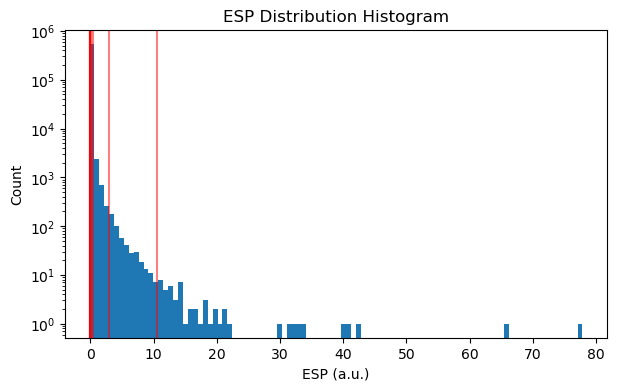

In [12]:
import matplotlib.pyplot as plt
flat = esp_grid.flatten()

plt.figure(figsize=(7,4))
plt.hist(flat, bins=100, color='C0')
plt.xlabel("ESP (a.u.)")
plt.ylabel("Count")
plt.yscale("log") # log scale on the y axis to deal with most of the box being empty space
plt.title("ESP Distribution Histogram")
p = np.percentile(flat, [1, 5, 25, 50, 75, 95, 99, 99.9, 99.99])
for v in p:
    plt.axvline(v, color='r', alpha=0.5)
plt.show()

In [13]:
import psiresp

ModuleNotFoundError: No module named 'psiresp'